# Explorative Data Aanalysis of the $CH_4$ plumes 

This notebook explores the plumes downloaded as the EMIT-L2B product.

In [1]:
from datetime import datetime, timedelta
import json
from pathlib import Path
import earthaccess
import os
import glob
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from pyproj import Geod
from shapely.geometry import Point, Polygon, shape, box

In [3]:
cd "c:/Users/Julia/OneDrive/Dokumenty/WORK/PhD/IBM/CH4"

c:\Users\Julia\OneDrive\Dokumenty\WORK\PhD\IBM\CH4


In [4]:
gdf = gpd.read_file("emit_ch4/emit_ch4_plumes_metadata.gpkg")

In [6]:
gdf.head()

,name,latitude (centroid),longitude (centroid),area_km2,bounds,width_km,height_km,startDate,endDate,max_ch4_concentration,concentration_uncertainty,geometry
0,20220810T064957_000485,31.123154,35.206945,6.269775,"(35.1922411, 31.1113516, 35.2226061, 31.135752)",2.896241,2.705311,2022-08-10T06:49:57Z,2022-08-10T06:49:57Z,2895.0,553.0,"POLYGON ((35.20309 31.13575, 35.19549 31.13521..."
1,20220810T065021_000486,31.905596,36.229274,2.265073,"(36.2213984, 31.8975887, 36.2382076, 31.9133135)",1.589982,1.743647,2022-08-10T06:49:57Z,2022-08-10T06:49:57Z,1331.0,343.0,"POLYGON ((36.22574 31.91331, 36.2214 31.9106, ..."
2,20220810T065132_000487,35.299036,40.464131,3.403105,"(40.4421363, 35.2919643, 40.4844305, 35.3082313)",3.846811,1.804760,2022-08-10T06:49:57Z,2022-08-10T06:49:57Z,3401.0,526.0,"POLYGON ((40.45135 35.30823, 40.44214 35.30769..."
3,20220810T065132_000496,35.279094,40.508176,8.382147,"(40.4865994, 35.2664794, 40.5310625, 35.293591)",4.045078,3.007916,2022-08-10T06:49:57Z,2022-08-10T06:49:57Z,1364.0,308.0,"POLYGON ((40.49256 35.29359, 40.48823 35.29088..."
4,20220811T042630_000490,22.340710,56.404999,8.274078,"(56.3929904, 22.3163401, 56.4173908, 22.3629721)",2.513594,5.163789,2022-08-11T04:26:30Z,2022-08-11T04:26:30Z,1312.0,383.0,"POLYGON ((56.40329 22.36297, 56.39733 22.36189..."


In [7]:
print(f"max width = {gdf["width_km"].max()} \nmax height = {gdf["height_km"].max()}")
print(f"min width = {gdf["width_km"].min()} \nmin height = {gdf["height_km"].min()}")
print(f"mean width = {gdf["width_km"].mean()} \nmean height = {gdf["height_km"].mean()}")
print(f"median width = {gdf["width_km"].median()} \nmedian height = {gdf["height_km"].median()}")
print(f"min area = {gdf["area_km2"].min()} \nmax area = {gdf["area_km2"].max()} \nmean area = {gdf["area_km2"].mean()} \nmedian area = {gdf["area_km2"].median()}")

max width = 70.18868423988263 
max height = 69.56130176294003
min width = 0.35848364894087054 
min height = 0.3006051294168854
mean width = 4.361090966294492 
mean height = 4.125987993074411
median width = 2.4855036745052947 
median height = 2.4668634011897046
min area = 0.112647509383291 
max area = 522.1092912657741 
mean area = 15.852319200044791 
median area = 3.467065109104112


### Checking the area of plumes distribution (long right tail)

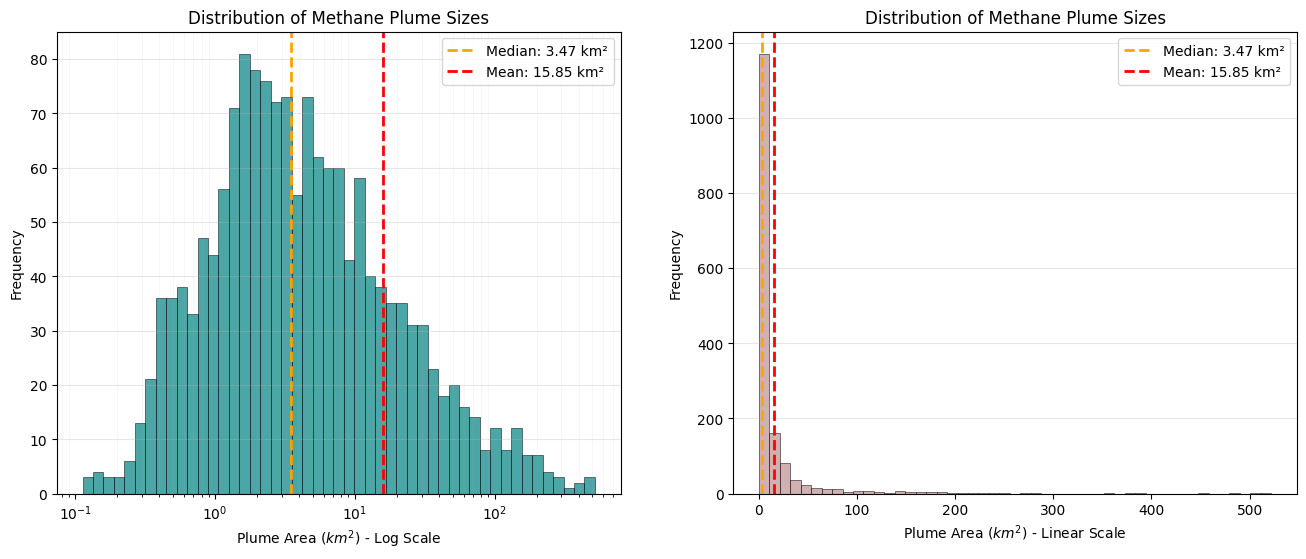

In [10]:
data = gdf[gdf["area_km2"] > 0]["area_km2"]
bins_log = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
bins_lin = np.linspace(data.min(), data.max(), 50)

plt.subplots(1, 2, figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.hist(
    data, 
    bins=bins_log, 
    color='teal', 
    edgecolor='black', 
    alpha=0.7,
    linewidth=0.5
)
plt.xscale('log')
plt.axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f} km²')
plt.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f} km²')
plt.xlabel("Plume Area ($km^2$) - Log Scale")
plt.ylabel("Frequency")
plt.title("Distribution of Methane Plume Sizes")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', which='minor', alpha=0.1) # Minor grid for log scale

plt.subplot(1, 2, 2)
plt.hist(
    data, 
    bins=bins_lin, 
    color='rosybrown', 
    edgecolor='black', 
    alpha=0.7,
    linewidth=0.5
)
plt.axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f} km²')
plt.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f} km²')
plt.xlabel("Plume Area ($km^2$) - Linear Scale")
plt.ylabel("Frequency")
plt.title("Distribution of Methane Plume Sizes")
plt.legend()
plt.grid(axis='y', alpha=0.3)   
plt.grid(axis='x', which='minor', alpha=0.1) # Minor grid for linear scale

plt.show()

In [11]:
print(f"Number of plumes with area > 100 km²: {len(gdf[gdf['area_km2'] > 100])}")
print(f"Number of plumes with area 10-100 km²: {len(gdf[(gdf['area_km2'] > 10) & (gdf['area_km2'] <= 100)])}")
print(f"Number of plumes with area 5-10 km²: {len(gdf[(gdf['area_km2'] > 5) & (gdf['area_km2'] <= 10)])}")
print(f"Number of plumes with area 1-5 km²: {len(gdf[(gdf['area_km2'] > 1) & (gdf['area_km2'] <= 5)])}")    
print(f"Number of plumes with area < 1 km²: {len(gdf[gdf['area_km2'] < 1])}")

Number of plumes with area > 100 km²: 54
Number of plumes with area 10-100 km²: 373
Number of plumes with area 5-10 km²: 224
Number of plumes with area 1-5 km²: 649
Number of plumes with area < 1 km²: 274


In [8]:
them40 = gdf[(gdf["width_km"] > 25) | (gdf["height_km"] > 25)]

biggest5 = gdf.iloc[[1090, 936, 1001, 1493, 1294]]

print(them40["area_km2"].sum()/gdf["area_km2"].sum())
print(biggest5["area_km2"].sum()/gdf["area_km2"].sum())

0.32785244563084825
0.09473495970953191


In [9]:
them40.to_csv("irregular_plumes.csv", index=False)

In [11]:
overwater = biggest5.iloc[[3, 4]]

In [13]:
overwater["area_km2"].sum()/gdf["area_km2"].sum()

np.float64(0.03414469890158344)

In [18]:
them40_sorted = them40.sort_values(by="area_km2", ascending=False)
them40_sorted_names = list(them40_sorted['name'])

In [ ]:
print(f"Plumes with 512x512 chip: {len(gdf[(gdf["width_km"] < 25) & (gdf["height_km"] < 25)])}")
print(f"Plumes fitting in one 128x128 chip: {len(gdf[(gdf["width_km"] < 7.68) & (gdf["height_km"] < 7.68)])}")
print(f"Plumes fitting in one 128x128 chip (area): {len(gdf[(gdf["area_km2"] < 58.9824)])}")

Plumes with 512x512 chip: 1534
Plumes fitting in one 128x128 chip: 1297
Plumes fitting in one 128x128 chip (area): 1482


,name,latitude (centroid),longitude (centroid),area_km2,bounds,width_km,height_km,startDate,endDate,max_ch4_concentration,concentration_uncertainty,geometry
628,20230629T044014_000112,40.088362,60.88301,68.710512,"(60.7536243, 40.0473435, 61.0480566, 40.1145803)",25.112979,7.465718,2023-06-29T04:40:14Z,2023-06-29T04:40:14Z,4240.0,204.0,"POLYGON ((60.80134 40.11458, 60.75796 40.11404..."


### Check the distribution of Plume Concentration

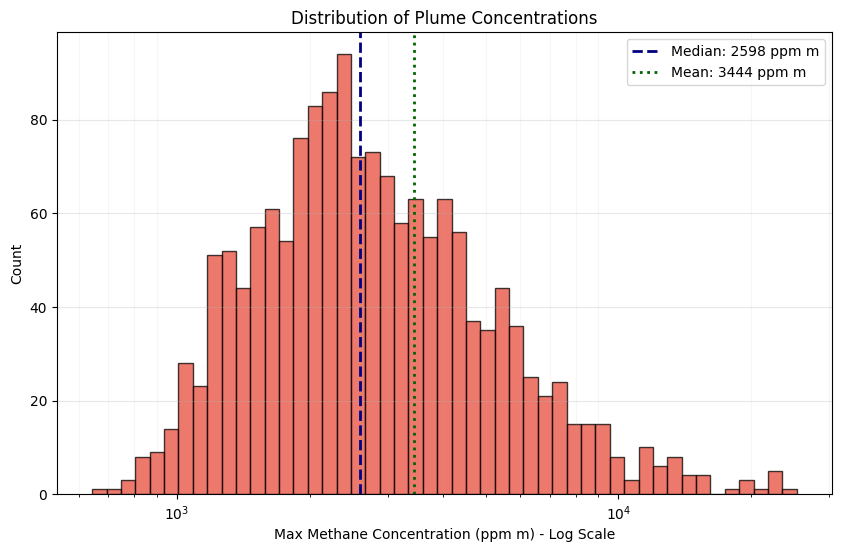

In [20]:
data = gdf[gdf["max_ch4_concentration"] > 0]["max_ch4_concentration"]

bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)

plt.figure(figsize=(10, 6))

plt.hist(
    data, 
    bins=bins, 
    color='#e74c3c',  
    edgecolor='black', 
    alpha=0.75
)

plt.xscale('log')

median_val = data.median()
mean_val = data.mean()

plt.axvline(median_val, color='navy', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f} ppm m')
plt.axvline(mean_val, color='darkgreen', linestyle=':', linewidth=2, label=f'Mean: {mean_val:.0f} ppm m')

plt.xlabel("Max Methane Concentration (ppm m) - Log Scale")
plt.ylabel("Count")
plt.title("Distribution of Plume Concentrations")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', which='minor', alpha=0.1) # helpful for log scales

plt.show()

### Visualizing the Signal to Noise Ratio

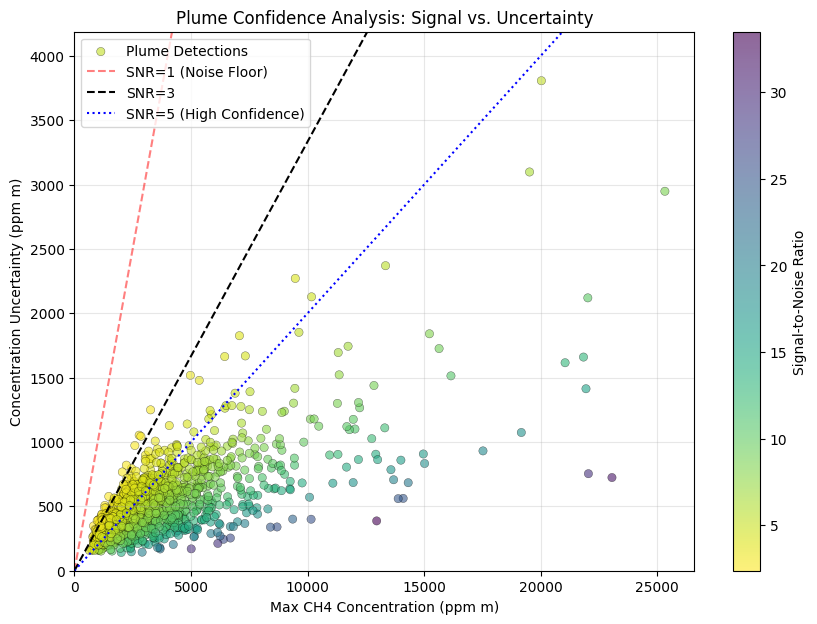

In [8]:
x_range = np.linspace(0, gdf["max_ch4_concentration"].max(), 100)
y_snr1 = x_range / 1
y_snr3 = x_range / 3
y_snr5 = x_range / 5

plt.figure(figsize=(10, 7))
snr_values = gdf["max_ch4_concentration"] / gdf["concentration_uncertainty"]
scatter = plt.scatter(
    gdf["max_ch4_concentration"], 
    gdf["concentration_uncertainty"], 
    c=snr_values, 
    cmap='viridis_r', 
    alpha=0.6, 
    edgecolor='k', 
    linewidth=0.3,
    label='Plume Detections'
)
plt.plot(x_range, y_snr1, 'r--', label='SNR=1 (Noise Floor)', alpha=0.5)
plt.plot(x_range, y_snr3, 'k--', label='SNR=3', linewidth=1.5)
plt.plot(x_range, y_snr5, 'b:', label='SNR=5 (High Confidence)', linewidth=1.5)

plt.colorbar(scatter, label='Signal-to-Noise Ratio')
plt.xlabel("Max CH4 Concentration (ppm m)")
plt.ylabel("Concentration Uncertainty (ppm m)")
plt.title("Plume Confidence Analysis: Signal vs. Uncertainty")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.xlim(0, gdf["max_ch4_concentration"].max() * 1.05)
plt.ylim(0, gdf["concentration_uncertainty"].max() * 1.1)

plt.show()

In [9]:
gdf = gdf.loc[(gdf["max_ch4_concentration"] / gdf["concentration_uncertainty"]) > 3]
print(f"Number of plumes with SNR < 3: {len(gdf.loc[(gdf["max_ch4_concentration"] / gdf["concentration_uncertainty"]) < 3])}")

Number of plumes with SNR < 3: 0


### Visualizing the distribution in time

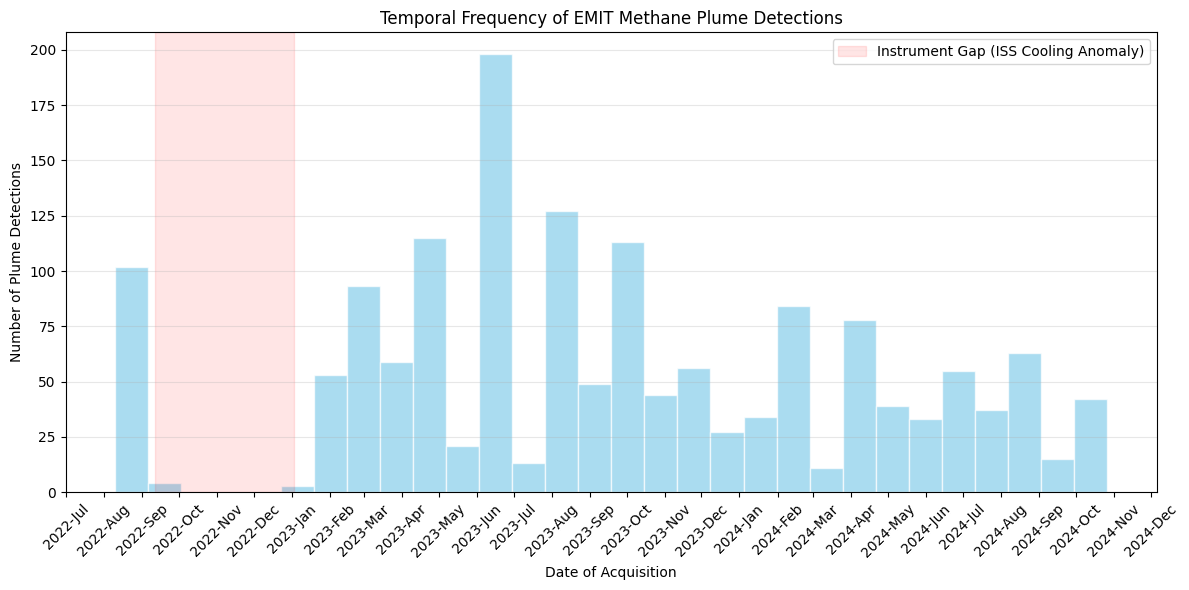

In [23]:
import matplotlib.dates as mdates

gdf["startDate"] = pd.to_datetime(gdf["startDate"], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 6))
counts, bins, patches = ax.hist(
    gdf["startDate"],
    bins=30,
    color='skyblue',
    edgecolor='white',
    alpha=0.7
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))

plt.xticks(rotation=45)
plt.xlabel("Date of Acquisition")
plt.ylabel("Number of Plume Detections")
plt.title("Temporal Frequency of EMIT Methane Plume Detections")
plt.grid(axis='y', alpha=0.3)

ax.axvspan(pd.to_datetime('2022-09-12'), pd.to_datetime('2023-01-03'), color='red', alpha=0.1, label='Instrument Gap (ISS Cooling Anomaly)')
ax.legend()

plt.tight_layout()
plt.show()

### Visualize the geographical distribution

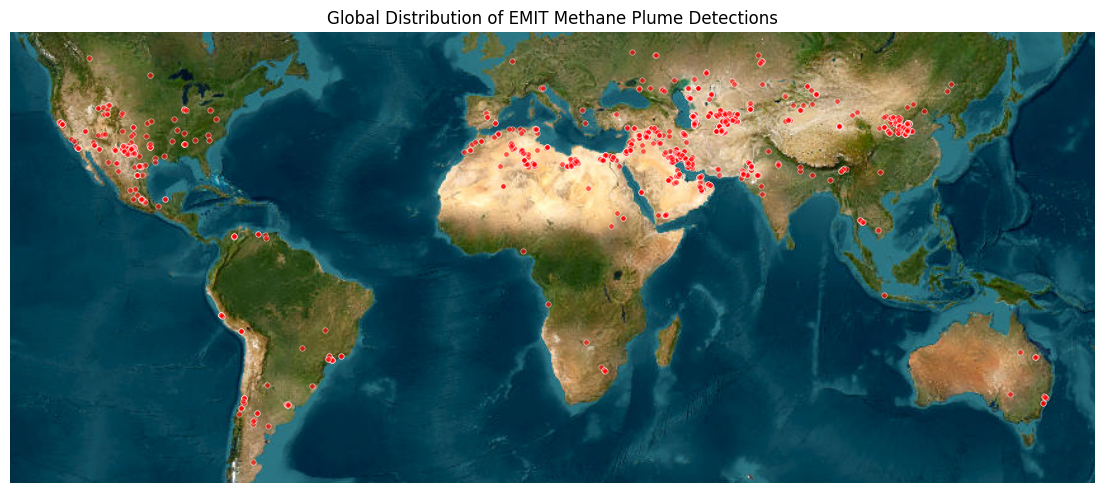

In [10]:
import geopandas as gpd
import contextily as ctx
gdf_points = gpd.GeoDataFrame(
     gdf, 
     geometry=gpd.points_from_xy(gdf["longitude (centroid)"], gdf["latitude (centroid)"]),
     crs="EPSG:4326"  
 )

gdf_web = gdf_points.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(14, 10))
gdf_web.plot(
    ax=ax, 
    markersize=15, 
    color='red', 
    alpha=0.6, 
    edgecolor='white', 
    linewidth=0.5
)
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution=False)

ax.set_axis_off()
plt.title("Global Distribution of EMIT Methane Plume Detections")
plt.show()

In [11]:
gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs="EPSG:4326")
import folium
#biggest5show = gpd.GeoDataFrame(biggest5, geometry='geometry', crs="EPSG:4326")

m = gdf.explore(
    column="max_ch4_concentration",
    cmap="plasma",
    tiles="CartoDB positron",
    style_kwds={"weight": 2, "fillOpacity": 0.4},
    tooltip=[
        "name", 
        "startDate", 
        "max_ch4_concentration", 
        "area_km2"
    ],
    popup=True
)
areas_gdf.explore(
    m=m,                      # <-- This tells it to plot on top of your existing map
    color="red",              # Make the boxes distinctly visible
    style_kwds={"weight": 2, "fillOpacity": 0.05, "dashArray": "5, 5"}, # Dashed outline, hollow fill
    tooltip=["region"],       # Shows region name on hover
    name="Areas of Interest", # Named for the layer control
    popup=False
)
folium.LayerControl().add_to(m)
m.add_child(folium.LatLngPopup())
m

### plot GEE download example

In [6]:
dataset = rio.open("emit_ch4/20230223T063033_000710_image.tif")
mask = rio.open("emit_ch4/20230223T063033_000710_mask.tif")
plume = rio.open("./emit_ch4/data/PLUMES_25KM+/EMIT_L2B_CH4PLM_001_20230223T063033_000710.tif")
image = dataset.read([37, 24, 13])
mask = mask.read(1)
plume = plume.read(1)

In [69]:
cropped = mask.shape

(552, 164)

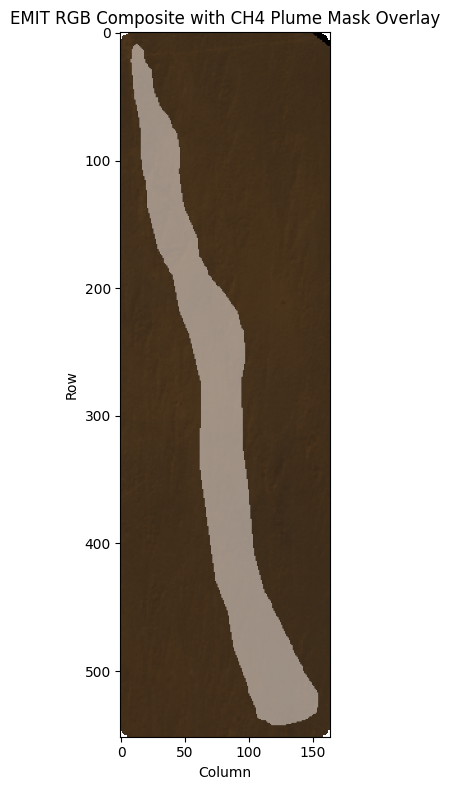

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

# Display the RGB image
ax.imshow(np.transpose(image, (1, 2, 0)))

# Overlay the mask with transparency
masked = np.ma.masked_where(mask == 0, mask)
ax.imshow(masked, cmap='Reds', alpha=0.5)

ax.set_title('EMIT RGB Composite with CH4 Plume Mask Overlay')
ax.set_xlabel('Column')
ax.set_ylabel('Row')
plt.tight_layout()
plt.show()

In [14]:
from terratorch import BACKBONE_REGISTRY
len(list(BACKBONE_REGISTRY))

1385

## Authenticate and explore collections

In [18]:
earthaccess.login(persist=True)

In [19]:
Query = earthaccess.collection_query().keyword('emit')
print(f'Collections found: {Query.hits()}')

Collections found: 61


In [20]:
collections = Query.fields(['ShortName']).get()

In [21]:
short_names = [product['short-name'] for product in [collection.summary() for collection in collections]]

In [22]:
EMIT_L2B_CH4 = 'EMITL2BCH4PLM'
EMIT_L2A_RFL = 'EMITL2ARFL'
EMIT_L1B_RAD = 'EMITL1BRAD'

In [28]:
plume_results = earthaccess.search_data(short_name=EMIT_L2B_CH4)
plume = plume_results[0]

In [29]:
date_format = '%Y-%m-%dT%H:%M:%SZ'
start_date = datetime.strptime(plume['umm']['TemporalExtent']['SingleDateTime'], date_format)
start_date = start_date.replace(hour=0, minute=0, second=0, microsecond=0)
end_date = start_date + timedelta(days=1)
start_date = start_date.strftime(date_format)
end_date = end_date.strftime(date_format)

In [ ]:
points = plume['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0]['Boundary']['Points']
polygon = gpd.GeoSeries(Polygon([(p['Longitude'], p['Latitude']) for p in points]))

rep = polygon.representative_point()[0]

scene_id = plume['umm']['AdditionalAttributes'][5]['Values'][0][-3:]

In [43]:
plume['umm']['AdditionalAttributes'][5]


{'Name': 'SOURCE_SCENES',
 'Values': ['EMIT_L2B_CH4ENH_V001_20220810T064957_2222205_033']}

In [31]:
start_date, end_date

('2022-08-10T00:00:00Z', '2022-08-11T00:00:00Z')

In [ ]:
query_res = earthaccess.search_data(short_name=EMIT_L2A_RFL,
                                    point=(rep.x, rep.y),
                                    temporal=(start_date[:10], end_date[:10]))

In [45]:
scene_ids = [q['meta']['native-id'][-3:] for q in query_res]
idx = scene_ids.index(scene_id)

In [46]:
scene_ids

['033']

In [34]:
plume

Collection: {'ShortName': 'EMITL2BCH4PLM', 'Version': '001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 35.2030857, 'Latitude': 31.135752}, {'Longitude': 35.1954945, 'Latitude': 31.1352098}, {'Longitude': 35.1927833, 'Latitude': 31.1319564}, {'Longitude': 35.1922411, 'Latitude': 31.1227384}, {'Longitude': 35.1938678, 'Latitude': 31.1200273}, {'Longitude': 35.19441, 'Latitude': 31.1167739}, {'Longitude': 35.1982056, 'Latitude': 31.1129783}, {'Longitude': 35.2025435, 'Latitude': 31.1113516}, {'Longitude': 35.2123037, 'Latitude': 31.1113516}, {'Longitude': 35.2193527, 'Latitude': 31.1140627}, {'Longitude': 35.2215216, 'Latitude': 31.1162317}, {'Longitude': 35.2215216, 'Latitude': 31.1178584}, {'Longitude': 35.2226061, 'Latitude': 31.1189428}, {'Longitude': 35.2220638, 'Latitude': 31.1265341}, {'Longitude': 35.2193527, 'Latitude': 31.1308719}, {'Longitude': 35.2133881, 'Latitude': 31.1330409}, {'Longitude': 35.2057969, 'Latitude': 31.1330409}, {'Longitude': 35.2030857, 'Latitude': 31.135752}]}}]}}}
Temporal coverage: {'SingleDateTime': '2022-08-10T06:49:57Z'}
Size(MB): 0.018007278442382812
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2BCH4PLM.001/EMIT_L2B_CH4PLM_001_20220810T064957_000485/EMIT_L2B_CH4PLM_001_20220810T064957_000485.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2BCH4PLM.001/EMIT_L2B_CH4PLM_001_20220810T064957_000485/EMIT_L2B_CH4PLMMETA_001_20220810T064957_000485.json']

In [40]:
len(scene_ids)

195

In [35]:
emit_og_img = query_res[idx]
emit_og_img['umm']

{'TemporalExtent': {'RangeDateTime': {'BeginningDateTime': '2022-08-10T05:25:40Z',
   'EndingDateTime': '2022-08-10T05:26:00Z'}},
 'GranuleUR': 'EMIT_L2A_RFL_001_20220810T052540_2222204_033',
 'AdditionalAttributes': [{'Name': 'SOFTWARE_BUILD_VERSION',
   'Values': ['010609']},
  {'Name': 'Identifier_product_doi_authority', 'Values': ['https://doi.org']},
  {'Name': 'Identifier_product_doi',
   'Values': ['10.5067/EMIT/EMITL2ARFL.001']},
  {'Name': 'ORBIT', 'Values': ['2222204']},
  {'Name': 'ORBIT_SEGMENT', 'Values': ['10']},
  {'Name': 'SCENE', 'Values': ['33']},
  {'Name': 'SOLAR_ZENITH', 'Values': ['8.25']},
  {'Name': 'SOLAR_AZIMUTH', 'Values': ['73.97']}],
 'SpatialExtent': {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 95.18513488769531,
         'Latitude': 49.78916931152344},
        {'Longitude': 93.10723876953125, 'Latitude': 49.29852294921875},
        {'Longitude': 93.28178405761719, 'Latitude': 48.559295654296875},
        {

In [ ]:
plume['Image_URL'] = query_res[idx]["umm"]["RelatedUrls"]